# 💰 Modelo de Costos y Rentabilidad

## Contexto
Con el dataset limpio de precios de mercado, construí un modelo económico que calcula
la **ganancia neta mensual** de un conductor de Cabify para cada auto analizado.

## Fuentes de los parámetros
- **Ingresos brutos:** relevamiento de iProfesional a más de 25 choferes activos en AMBA (2025).
  Un conductor trabajando jornada completa (8hs, lunes a sábado) genera entre $1.600.000
  y $2.400.000 brutos mensuales. Usé el valor medio de $2.000.000.
- **Comisión Cabify:** 12,5% oficial para viajes de usuarios privados en GBA.
- **Tipo de cambio:** scrapeado en tiempo real desde dolarhoy.com (dólar blue, venta).
  Uso el blue porque el mercado de autos usados en Argentina se referencia al dólar libre.

## Fórmula central del modelo
```
Ganancia Neta = Ingresos Brutos
              - Comisión Cabify (12.5%)
              - Combustible mensual
              - Amortización del vehículo
              - Seguro
              - Patente prorrateada
```

### Parámetros y función de rentabilidad

El modelo está implementado en `src/modelo.py` como una función pura que recibe
el precio de compra del auto y su consumo, y devuelve un diccionario con todos
los componentes del cálculo desagregados.

**Decisión de diseño:** separé el modelo en `src/` y no en el notebook porque
es código reutilizable — lo voy a llamar desde la simulación de Montecarlo también.
Mezclar lógica de negocio con presentación en un notebook es mala práctica.

In [1]:
import pandas as pd
import requests
import sys
from bs4 import BeautifulSoup
sys.path.append("..")
from src.modelo import calcular_rentabilidad, PARAMETROS, MANTENIMIENTO_POR_KM_ARS

df = pd.read_csv("../data/processed/precios_autos_procesado.csv")

def get_tipo_cambio():
    url = "https://dolarhoy.com/"
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    valores = soup.find_all("div", class_="val")
    venta_blue = valores[5].text.strip().replace("$", "").replace(".", "").replace(",", ".")
    return float(venta_blue)

TIPO_CAMBIO = get_tipo_cambio()
print(f"Tipo de cambio: ${TIPO_CAMBIO:,.0f} ARS/USD")
print(f"Parámetros del modelo:\n{PARAMETROS}")

Tipo de cambio: $1,500 ARS/USD
Parámetros del modelo:
{'ingreso_bruto_mensual_ars': 2000000, 'comision_cabify': 0.125, 'km_diarios': 150, 'dias_laborales_mes': 26, 'precio_nafta_ars_litro': 2034, 'precio_gnc_ars_m3': 500, 'seguro_pct_mensual': 0.012, 'seguro_piso_ars': 140000, 'patente_pct_anual': 0.045, 'valor_fiscal_pct': 0.8, 'vida_util_km': 300000, 'valor_residual_pct': 0.35}


### Datos técnicos de consumo por modelo

Para calcular el costo de combustible necesito el consumo en L/100km de cada auto.
Estos datos provienen de las fichas técnicas oficiales de cada fabricante,
contrastadas con relevamientos de consumo real en ciudad de foros especializados
(Autocosmos, Club del auto). Uso el consumo en ciudad porque un chofer de Cabify
opera principalmente en zona urbana.

### Resultados del modelo

Aplico el modelo a cada auto usando el **precio mediano** del mercado como
precio de compra. Uso la mediana y no el promedio porque es más robusta ante
valores extremos — el 50% de las publicaciones están por debajo de ese precio,
lo que representa una compra realista para un conductor promedio.

In [2]:
# Datos técnicos de consumo por modelo (L/100km en ciudad, fuente: fichas técnicas)
consumo_por_modelo = {
    "Toyota Etios":        8.5,
    "Toyota Corolla":      9.0,
    "Toyota Yaris":        8.0,
    "Chevrolet Prisma":    8.5,
    "Chevrolet Onix Plus": 7.8,
    "Renault Logan":       8.0,
    "Nissan Versa":        9.0,
    "VW Virtus":           8.5,
    "VW Voyage":           9.5,
    "VW Gol":              9.0,
    "Ford Ka":             8.0,
    "Ford Fiesta":         9.0,
    "Fiat Siena":          9.5,
    "Fiat Cronos":         8.4,
    "Peugeot 208":         7.5,
}

# GNC disponible para estos modelos (mercado de usados con equipo instalado)
tiene_gnc = {
    "Toyota Etios":        False,
    "Toyota Corolla":      False,
    "Toyota Yaris":        False,
    "Chevrolet Prisma":    True,
    "Chevrolet Onix Plus": False,   # motor turbo — no recomendado para GNC
    "Renault Logan":       True,
    "Nissan Versa":        False,
    "VW Virtus":           False,
    "VW Voyage":           True,
    "VW Gol":              True,
    "Ford Ka":             False,
    "Ford Fiesta":         False,
    "Fiat Siena":          True,
    "Fiat Cronos":         True,    # muy común con GNC en apps de transporte
    "Peugeot 208":         False,
}

# Precio mediano por modelo desde el dataset
precio_mediano = df.groupby("modelo")["precio_usd"].median()

# Aplicar modelo a cada auto (v2: incluye mantenimiento por km,
# valor residual y seguro/patente proporcionales al valor del auto)
resultados = []
for modelo in consumo_por_modelo:
    precio = precio_mediano[modelo]
    resultado = calcular_rentabilidad(
        precio_compra_usd=precio,
        consumo_l_100km=consumo_por_modelo[modelo],
        tiene_gnc=tiene_gnc[modelo],
        tipo_cambio=TIPO_CAMBIO,
        costo_mantenimiento_km=MANTENIMIENTO_POR_KM_ARS[modelo]
    )
    resultado["modelo"] = modelo
    resultado["tiene_gnc"] = tiene_gnc[modelo]
    resultados.append(resultado)

df_resultados = pd.DataFrame(resultados).set_index("modelo")

# Mostrar tabla resumen
cols_mostrar = ["precio_compra_usd", "ganancia_neta_usd", "ganancia_neta_ars",
                "payback_meses", "costo_combustible_ars", "amortizacion_mensual_ars",
                "mantenimiento_mensual_ars", "seguro_mensual_ars", "patente_mensual_ars"]

print(df_resultados[cols_mostrar].sort_values("ganancia_neta_usd", ascending=False).round(0).to_string())

                     precio_compra_usd  ganancia_neta_usd  ganancia_neta_ars  payback_meses  costo_combustible_ars  amortizacion_mensual_ars  mantenimiento_mensual_ars  seguro_mensual_ars  patente_mensual_ars
modelo                                                                                                                                                                                                          
Fiat Siena                      8653.0              626.0           938619.0           14.0               195000.0                  109681.0                     312000            155760.0              38940.0
VW Voyage                       9867.0              571.0           856940.0           17.0               195000.0                  125060.0                     351000            177600.0              44400.0
Chevrolet Prisma                9933.0              570.0           854595.0           17.0               195000.0                  125905.0                     351

### ⚠️ Supuesto asumido: mantenimiento de equipo GNC

Los autos con GNC en el dataset son unidades usadas que ya tienen el equipo instalado.
El costo del equipo está implícitamente absorbido en el precio de compra de mercado.

Lo que el modelo **no incluye** es el mantenimiento periódico del equipo GNC:
- Revisión obligatoria cada 2 años
- Cambio de válvulas y mangueras según km

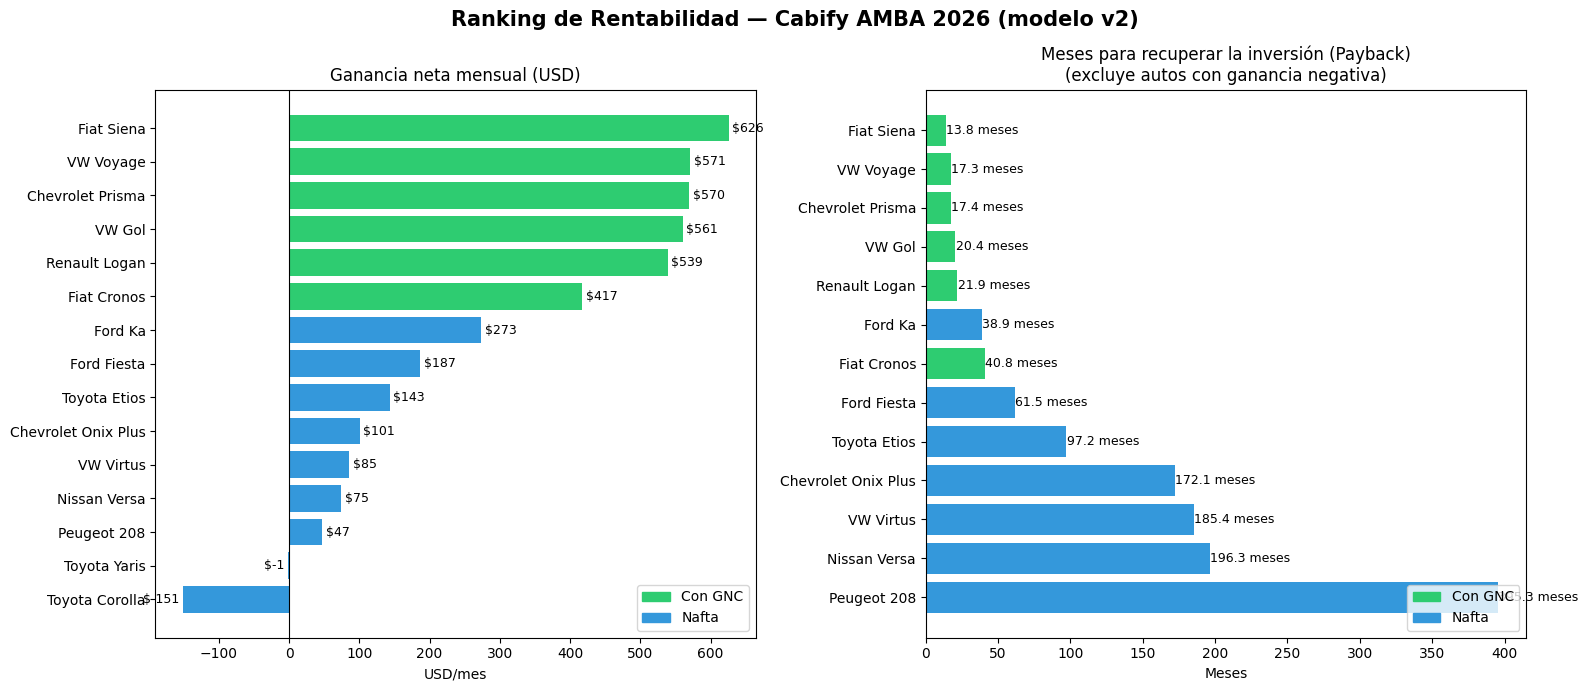

Gráfico guardado.


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Ranking de Rentabilidad — Cabify AMBA 2026 (modelo v2)", fontsize=15, fontweight="bold")

df_plot = df_resultados.sort_values("ganancia_neta_usd", ascending=True)
colores = ["#2ecc71" if df_resultados.loc[m, "tiene_gnc"] else "#3498db" for m in df_plot.index]

# 1. Ganancia neta mensual en USD
bars = axes[0].barh(df_plot.index, df_plot["ganancia_neta_usd"], color=colores)
axes[0].set_title("Ganancia neta mensual (USD)", fontsize=12)
axes[0].set_xlabel("USD/mes")
axes[0].axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(df_plot["ganancia_neta_usd"]):
    offset = 5 if v >= 0 else -5
    ha = "left" if v >= 0 else "right"
    axes[0].text(v + offset, i, f"${v:,.0f}", va="center", ha=ha, fontsize=9)

patch_gnc = mpatches.Patch(color="#2ecc71", label="Con GNC")
patch_nafta = mpatches.Patch(color="#3498db", label="Nafta")
axes[0].legend(handles=[patch_gnc, patch_nafta], loc="lower right")

# 2. Payback period en meses — solo autos con ganancia positiva (payback finito)
df_payback = df_resultados[np.isfinite(df_resultados["payback_meses"])]
df_plot2 = df_payback.sort_values("payback_meses", ascending=False)
colores2 = ["#2ecc71" if df_resultados.loc[m, "tiene_gnc"] else "#3498db" for m in df_plot2.index]
axes[1].barh(df_plot2.index, df_plot2["payback_meses"], color=colores2)
axes[1].set_title("Meses para recuperar la inversión (Payback)\n(excluye autos con ganancia negativa)", fontsize=12)
axes[1].set_xlabel("Meses")
for i, v in enumerate(df_plot2["payback_meses"]):
    axes[1].text(v + 0.2, i, f"{v:.1f} meses", va="center", fontsize=9)
axes[1].legend(handles=[patch_gnc, patch_nafta], loc="lower right")

plt.tight_layout()
plt.savefig("../reports/figures/02_ranking_rentabilidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Interpretación del ranking (modelo v2)

El modelo v2 incorpora cuatro costos que la versión anterior ignoraba o
simplificaba: **mantenimiento por km**, **valor residual** en la amortización,
y **seguro/patente proporcionales al valor del auto**. El resultado es un
ranking más realista y mucho más exigente:

1. **Combustible sigue siendo el factor dominante:** los autos con GNC gastan
   ~$195.000 ARS/mes contra $595.000-$714.000 de los de nafta. Los 6 modelos
   con GNC ocupan los 6 primeros puestos.

2. **El mantenimiento achata las ganancias de todos:** entre $312.000 y $468.000
   ARS/mes según el modelo (~$208-312 USD). Es el segundo costo más grande
   después del combustible en los autos a nafta, y el más grande en los GNC.

3. **Dos autos pasaron a ganancia negativa:** con todos los costos reales,
   el **Toyota Yaris (-$1 USD/mes)** y el **Toyota Corolla (-$151 USD/mes)**
   directamente no son negocio para Cabify con ingreso bruto de $2M — su
   amortización, seguro, patente y mantenimiento superan lo que generan.

4. **El precio de compra pega triple ahora:** define la amortización, el seguro
   (1,2% mensual del valor) y la patente (4,5% anual del valor fiscal). Por eso
   la brecha entre el Fiat Siena ($8.653 USD → $626 USD/mes de ganancia,
   payback 14 meses) y el Fiat Cronos ($17.000 USD → $417 USD/mes, payback 41
   meses) se amplió a pesar de que ambos tienen GNC.

**Conclusión:** el auto ideal para Cabify combina bajo precio de entrada con
GNC y mantenimiento barato. El Fiat Siena reúne las tres cosas ($80/km de
mantenimiento, el más bajo junto al VW Gol) y lidera con $626 USD/mes.